In [1]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [10]:
filename = r'..\data\results\game_metrics.csv'
df = pd.read_csv(filename) 
df = df.loc[df.subject != '24EK']

In [11]:
df.head()

,total_score,available_points,relative_score,game_duration,score_min,score_sec,vel_good,vel_good_all,p_green_steps,p_good_steps,aver_time,green_steps_min,n_hh,n,hh_percent,n_hh_average,n_overkill_average,mode,n_game,subject
0,3873,5757,67.27,4.95,782.42,13.04,31.07,19.80,84.55,70.19,9.85,34.42,2,22,9.09,0.10,0.55,im,1,01TG
1,3443,5867,58.68,5.45,631.74,10.53,26.79,17.95,85.84,69.36,11.20,32.14,4,24,16.67,0.20,1.00,im,2,01TG
2,3138,5622,55.82,5.53,567.45,9.46,23.42,11.84,81.98,63.31,11.40,28.16,5,25,20.00,0.25,0.90,im,3,01TG
3,3993,6087,65.60,7.92,504.17,8.40,19.24,15.39,96.55,74.44,17.15,23.44,18,38,47.37,0.90,1.20,qm,1,01TG
4,3738,5592,66.85,5.13,728.65,12.14,30.00,17.88,84.68,69.87,10.40,31.44,4,24,16.67,0.20,0.25,qm,2,01TG


In [12]:
df_av = []
for subject in df.subject.unique():
    for mode in ['im', 'qm']:
        df_curr = df.loc[(df.subject == subject) & (df['mode'] == mode)]
        df_average = df_curr.mean(numeric_only=True).round(2)
        df_average['absolute_score'] = df_curr['total_score'].sum()
        df_average['subject'] = subject
        df_average['mode'] = mode
        df_av.append(df_average)
df_av = pd.DataFrame(df_av)

In [13]:
df_av.head()

,total_score,available_points,relative_score,game_duration,score_min,score_sec,vel_good,vel_good_all,p_green_steps,p_good_steps,...,green_steps_min,n_hh,n,hh_percent,n_hh_average,n_overkill_average,n_game,absolute_score,subject,mode
0,3484.67,5748.67,60.59,5.31,660.54,11.01,27.09,16.53,84.12,67.62,...,31.57,3.67,23.67,15.25,0.18,0.82,2.0,10454.0,01TG,im
1,4089.67,6063.67,67.38,6.58,637.39,10.62,24.19,17.48,91.71,73.29,...,27.74,11.00,31.00,33.17,0.55,0.88,2.0,12269.0,01TG,qm
2,4165.33,5511.33,75.61,5.31,790.00,13.17,35.02,28.09,90.08,80.38,...,37.10,3.67,23.67,14.58,0.18,0.35,2.0,12496.0,02ES,im
3,3766.00,5674.00,66.06,8.61,469.70,7.83,19.83,14.37,85.41,73.33,...,22.14,20.00,40.00,47.42,1.00,0.65,2.0,11298.0,02ES,qm
4,3401.67,6211.67,54.81,5.30,643.29,10.72,23.40,13.27,88.71,62.48,...,33.23,1.33,21.33,5.93,0.07,1.77,2.0,10205.0,03AC,im


# interaction metrics

In [14]:
metrics = ['n_hh_average', 'p_green_steps', 'n_overkill_average']
ylabels = ['number of blocks', '% of green bands', 'number of outer bands']

for i, metric in enumerate(metrics):
    print(ylabels[i])
    for cond in ['im', 'qm']:
        df_mode_av = df_av.loc[df_av['mode'] == cond]
        av_mean, av_std = df_mode_av[metric].mean().round(2), df_mode_av[metric].std().round(2)
        m, std = [], []
        for n in [1, 2, 3]:
            df_game = df.loc[(df['mode'] == cond) & (df.n_game == n)]
            m.append(df_game[metric].mean().round(2))
            std.append(df_game[metric].std().round(2))
        print('{}. Average: {}±{}. Game 1: {}±{}. Game 2: {}±{}. Game 3: {}±{}.'.format(cond, av_mean, av_std, m[0], std[0], m[1], std[1], m[2], std[2]))

number of blocks
im. Average: 0.68±0.4. Game 1: 0.63±0.43. Game 2: 0.59±0.44. Game 3: 0.81±0.63.
qm. Average: 0.68±0.4. Game 1: 0.72±0.61. Game 2: 0.64±0.65. Game 3: 0.7±0.59.
% of green bands
im. Average: 81.33±8.88. Game 1: 81.13±11.33. Game 2: 80.63±11.45. Game 3: 82.24±8.73.
qm. Average: 81.2±12.6. Game 1: 79.0±15.28. Game 2: 82.36±13.96. Game 3: 82.07±16.41.
number of outer bands
im. Average: 0.91±0.4. Game 1: 0.7±0.37. Game 2: 0.95±0.57. Game 3: 1.08±0.71.
qm. Average: 0.87±0.36. Game 1: 0.83±0.45. Game 2: 0.94±0.55. Game 3: 0.85±0.37.


In [15]:
def create_plot(metric, df, df_av, ax1, ax2, title, ylabel):
    sns.set_style("ticks")
    sns.set_context("paper", font_scale=1.2)
    sns.boxplot(df_av, x='mode', y=metric, width=.35, whis=(0, 100), palette="coolwarm", ax=ax1)
    
    sns.swarmplot(df_av, y=metric, x='mode', color='black', alpha=.5, ax=ax1, s=3)
    sns.lineplot(df_av, y=metric, x='mode', hue='subject', 
                    legend=False, palette=['grey' for _ in range(len(df))], alpha=.6, ax=ax1)
    ax1.set_xlabel('Task')
    ax1.set_ylabel(ylabel)
    ax1.set_xticks(['im', 'qm'], ['IM', 'QM'])
    ax1.grid()
    
    legend_status = False if not metric in  ['n_overkill_average', 'vel_good_all'] else True

    df_new = df.copy()
    # df_new.loc[df_new['mode'] == 'im', 'n_game'] -= 0.05
    # df_new.loc[df_new['mode'] == 'qm', 'n_game'] += 0.05
    df_new.loc[df_new['mode'] == 'im', 'mode'] = 'IM'
    df_new.loc[df_new['mode'] == 'qm', 'mode'] = 'QM'
    # sns.lineplot(df_new.loc[df_new['mode'] == 'im'], x='n_game', y=metric, err_style='bars', color='cornflowerblue', markers=True, style='mode', ax=ax2, errorbar='pi')
    # sns.lineplot(df_new.loc[df_new['mode'] == 'qm'], x='n_game', y=metric, err_style='bars', color='salmon',markers=True, style='mode',  ax=ax2, errorbar='pi')
    sns.boxplot(df_new, x='n_game', y=metric, hue='mode', whis=(0, 100), palette="coolwarm", ax=ax2, legend=legend_status)
    sns.swarmplot(df_new,x='n_game', y=metric, hue='mode', dodge=True, color='black', alpha=.5, ax=ax2, s=3, legend=False)

    if metric == 'n_hh_average':
        ax2.hlines(2.0, 1.2, 2.2, color='k', alpha=.5)
        ax1.set_ylim(-0.1, 2.3)
        ax2.text(s='p < 0.5', x=1.45, y=2.07, fontsize=9)
    
    ax2.set_xlabel('Game')
    # if metric == 'n_overkill_average' or metric == ''
    if legend_status:
        ax2.legend(title='Task', loc=[1.03, 0.55])
    plt.suptitle(title, fontsize=14)
    ax2.grid()

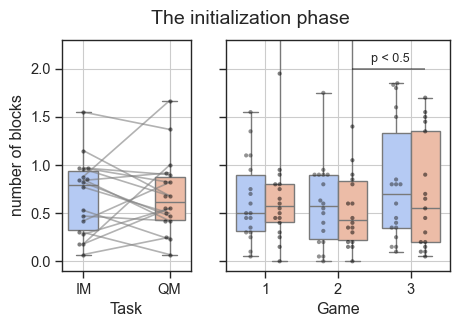

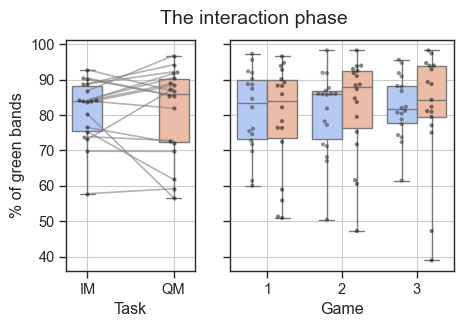

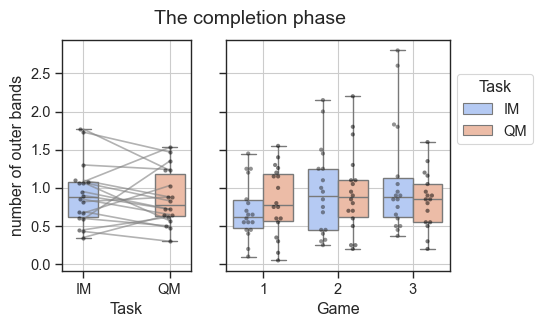

In [16]:
metrics = ['n_hh_average', 'p_green_steps', 'n_overkill_average']
titles = ['The initialization phase', 'The interaction phase', 'The completion phase']
ylabels = ['number of blocks', '% of green bands', 'number of outer bands']

for i in range(len(metrics)):
    fig, axes = plt.subplots(1, 2, figsize=(5, 3), width_ratios=[1, 1.75], sharey='row')
    create_plot(metrics[i], df, df_av, axes[0], axes[1], titles[i], ylabels[i])
    filename = os.path.join(r'..\data\results\pic\game_metrics', f'{titles[i]}.png')
    fig.savefig(filename, dpi=300,bbox_inches='tight')

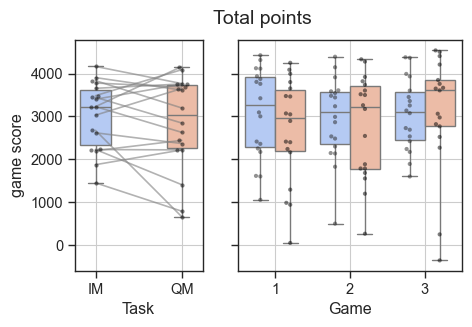

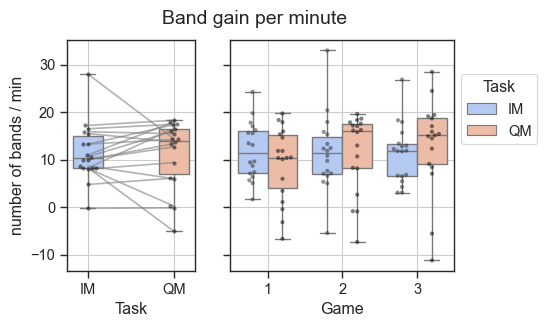

In [17]:
metrics = ['total_score', 'vel_good_all']
titles = ['Total points',  'Band gain per minute']
ylabels = ['game score',  'number of bands / min']

for i in range(len(metrics)):
    fig, axes = plt.subplots(1, 2, figsize=(5, 3), width_ratios=[1, 1.75], sharey='row')
    create_plot(metrics[i], df, df_av, axes[0], axes[1], titles[i], ylabels[i])
    filename = os.path.join(r'..\data\results\pic\game_metrics', f'{titles[i]}.png')
    fig.savefig(filename, dpi=300,bbox_inches='tight')

# survey

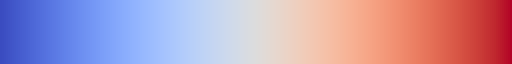

In [3]:
sns.color_palette("coolwarm", as_cmap=True)

In [4]:
filename = r'..\data\results\survey.xlsx'
df_surv = pd.read_excel(filename)
df_surv = pd.concat([df_surv.loc[df_surv['mode'] == 'im'], df_surv.loc[df_surv['mode'] == 'qm']])
df_surv.loc[df_surv['mode'] == 'im', 'mode'] = 'IM'
df_surv.loc[df_surv['mode'] == 'qm', 'mode'] = 'QM'
df_surv.head()

,subj,Success,Difficulty,attention,mode,n,TaskFit,TaskOrScreen,Auto,BetterPlay
11,01TG,0.772222,0.390741,0.646296,IM,1,0.681481,0.496296,0.042593,0.257407
12,02ES,0.953704,0.961111,0.896296,IM,1,0.974074,0.253704,0.350000,0.985185
13,03AC,0.877778,0.420370,0.744444,IM,1,0.687037,0.135185,0.155556,0.085185
14,04AB,0.905556,0.507407,0.518519,IM,1,0.937037,0.183333,0.601852,1.000000
15,06KK,0.805556,0.820370,0.670370,IM,1,0.301852,0.661111,0.253704,0.025926


In [43]:
def create_plot_surv(metric, df, ax, title, ylabel, legend_status):
    sns.set_style("ticks")
    sns.set_context("paper", font_scale=1.2)

    sns.boxplot(df, x='n', y=metric, hue='mode', whis=(0, 100), palette="coolwarm", ax=ax, legend=legend_status)
    sns.swarmplot(df,x='n', y=metric, hue='mode', dodge=True, color='black', alpha=.5, ax=ax, s=3, legend=False)

    if metric == 'n_hh_average':
        ax.hlines(2.0, 1.2, 2.2, color='k', alpha=.5)
        ax.set_ylim(-0.1, 2.3)
        ax.text(s='p < 0.5', x=1.35, y=2.07, fontsize=8)
    ax.set_xlabel('Time')
    ax.set_ylabel(ylabel)
    ax.set_ylim(-0.05, 1.05)
    # if metric == 'n_overkill_average' or metric == ''
    if legend_status:
        ax.legend(title='Task', loc=[1.03, 0.55])
    plt.suptitle(title,  fontsize=14)
    ax.grid()

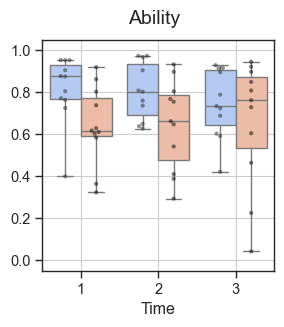

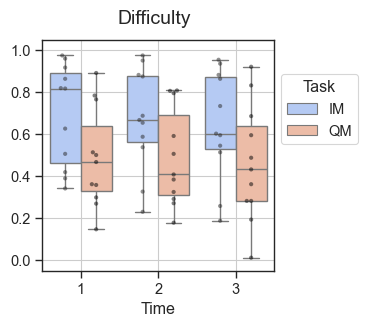

In [48]:
metrics = ['Success', 'Difficulty']
titles = ['Ability',  'Difficulty']
ylabels = ['',  '']

for i in range(len(metrics)):
    fig, axis = plt.subplots(1, figsize=(3, 3), width_ratios=[1], sharey='row')
    legend_status = True if metrics[i] == 'Difficulty' else False
    create_plot_surv(metrics[i], df_surv, axis, titles[i], ylabels[i], legend_status)
    filename = os.path.join(r'..\data\results\pic\surv_metrics', f'{titles[i]}.png')
    fig.savefig(filename, dpi=300,bbox_inches='tight')

In [53]:
def create_plot_surv_1(metric, df, ax, title, ylabel, color):
    sns.set_style("ticks")
    sns.set_context("paper", font_scale=1.2)

    sns.boxplot(df, x='n', y=metric, whis=(0, 100), width=0.5,color=color, ax=ax)
    sns.swarmplot(df,x='n', y=metric, dodge=True, color='black', alpha=.5, ax=ax, s=3, legend=False)

    if title == 'Amplitude Attention':
        ax.hlines(1.1, 0, 2, color='k', alpha=.5)
        ax.set_ylim(-0.05, 1.25)
        ax.text(s='p = 0.001', x=0.6, y=1.14, fontsize=10)
    else:
        ax.set_ylim(-0.05, 1.05)
    ax.set_xlabel('Time')
    ax.set_ylabel(ylabel)
    
    # if metric == 'n_overkill_average' or metric == ''
    # ax.legend(title='Task', loc=[1.03, 0.55])
    plt.suptitle(title, fontsize=14)
    ax.grid()

In [ ]:
metrics = ['attention', 'attention']
titles = ['Amplitude Attention',  'Vividness']
ylabels = ['',  '']

for i in range(len(metrics)):
    fig, axis = plt.subplots(1, figsize=(3, 3), width_ratios=[1], sharey='row')
    mode = 'QM' if i == 0 else 'IM'
    color = '#ecbca7' if i == 0 else '#b5caf3'
    create_plot_surv_1(metrics[i], df_surv.loc[df_surv['mode'] == mode], axis, titles[i], ylabels[i], color=color)
    filename = os.path.join(r'..\data\results\pic\surv_metrics', f'{titles[i]}.png')
    fig.savefig(filename, dpi=300,bbox_inches='tight')

In [63]:
def create_plot_surv_2(metric, df, ax, title, ylabel, color):
    sns.set_style("ticks")
    sns.set_context("paper", font_scale=1.2)

    sns.boxplot(df, x='mode', y=metric, whis=(0, 100),width=0.35, palette='coolwarm', ax=ax)
    sns.swarmplot(df, x='mode', y=metric, dodge=True, color='black', alpha=.5, ax=ax, s=3, legend=False)

    if title == 'Amplitude Attention':
        ax.hlines(1.1, 0, 2, color='k', alpha=.5)
        ax.set_ylim(-0.05, 1.25)
        ax.text(s='p = 0.001', x=0.6, y=1.14, fontsize=8)
    else:
        ax.set_ylim(-0.05, 1.05)
    ax.set_xlabel('Task')
    ax.set_ylabel(ylabel)
    
    # if metric == 'n_overkill_average' or metric == ''
    # ax.legend(title='Task', loc=[1.03, 0.55])
    plt.suptitle(title, fontsize=14)
    ax.grid()

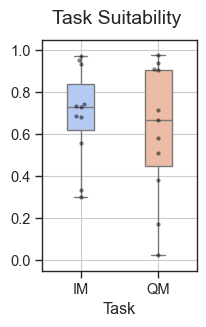

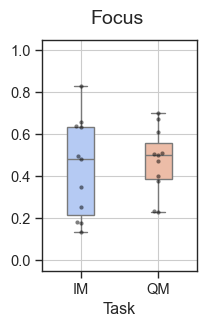

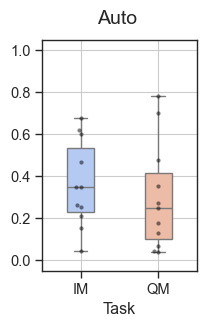

In [65]:
metrics = ['TaskFit', 'TaskOrScreen', 'Auto']
titles = ['Task Suitability',  'Focus', 'Auto']
ylabels = ['',  '', '']

for i in range(len(metrics)):
    fig, axis = plt.subplots(1, figsize=(2, 3), width_ratios=[1], sharey='row')
    # mode = 'qm' if i == 0 else 'im'
    # color = '#ecbca7' if i == 0 else '#b5caf3'
    create_plot_surv_2(metrics[i], df_surv.loc[df_surv.n == 1], axis, titles[i], ylabels[i], color=color)
    filename = os.path.join(r'..\data\results\pic\surv_metrics', f'{titles[i]}.png')
    fig.savefig(filename, dpi=300,bbox_inches='tight')

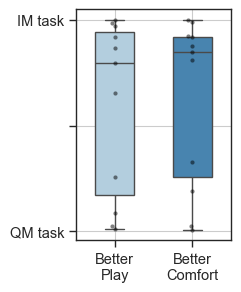

In [ ]:

metric = 'BetterPlay'
titles = ['Better\nPlay',  'Better\nComfort']

fig, ax = plt.subplots(1, figsize=(2, 3), width_ratios=[1], sharey='row')
sns.set_style("ticks")
sns.set_context("paper", font_scale=1.2)

sns.boxplot(df_surv, x='mode', y=metric, whis=(0, 100),width=0.5, palette='Blues', ax=ax)
sns.swarmplot(df_surv, x='mode', y=metric, dodge=True, color='black', alpha=.5, ax=ax, s=3, legend=False)

ax.set_xticks(['IM', 'QM'], titles)
ax.set_yticks([0, 0.5, 1], ['QM task', '', 'IM task'])
ax.set_xlabel('')
ax.set_ylabel('')

# if metric == 'n_overkill_average' or metric == ''
# ax.legend(title='Task', loc=[1.03, 0.55])
# plt.suptitle(title, y=1.02, fontsize=14)
ax.grid()
filename = os.path.join(r'..\data\results\pic\surv_metrics', f'better_play_and_comfort.png')
fig.savefig(filename, dpi=300,bbox_inches='tight')

In [104]:
fl = r'..\data\results\stat\clf_metrics.xlsx'
df_clf = pd.read_excel(fl)
df_av = []
for subject in df.subject.unique():
    for mode in ['im', 'qm']:
        df_curr = df_clf.loc[(df_clf.subject == subject) & (df_clf['mode'] == mode)]
        df_average = df_curr.mean(numeric_only=True).round(2)
        # df_average['absolute_score'] = df_curr['total_score'].sum()
        df_average['subject'] = subject
        df_average['mode'] = mode
        df_av.append(df_average)
df_av = pd.DataFrame(df_av)

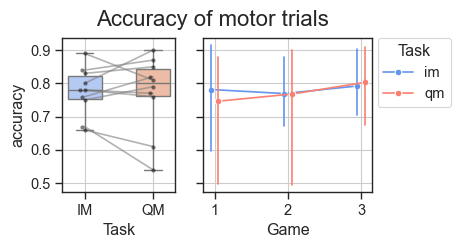

In [47]:
metrics = ['A_motor']
titles = ['Accuracy of motor trials']
ylabels = ['accuracy']

for i in range(len(metrics)):
    fig, axes = plt.subplots(1, 2, figsize=(4, 2), width_ratios=[1, 1.5], sharey='row')
    create_plot(metrics[i], df_clf, df_av, axes[0], axes[1], titles[i], ylabels[i])
    filename = os.path.join(r'..\data\results\pic', f'{metrics[i]}.png')
    fig.savefig(filename, dpi=300,bbox_inches='tight')

In [269]:
def create_plot(metric, df, df_av, axes):
    sns.boxplot(df_av, x='mode', y=metric, palette="coolwarm", ax=axes[0])
    sns.swarmplot(df_av, y=metric, x='mode', color='black', alpha=.5, ax=axes[0])
    sns.lineplot(df_av, y=metric, x='mode', hue='subject', 
                    legend=False, palette=['grey' for _ in range(len(df))], alpha=.6, ax=axes[0])
    axes[0].set_xticks(['im', 'qm'], ['IM', 'QM'])
    
    for i, mode in enumerate(['im', 'qm']):
        df_curr = df.loc[df['mode'] == mode].copy()
        curr_ax = axes[i+1]
        palette = "Blues" if mode == 'im' else "YlOrBr"
        sns.boxplot(df_curr, y=metric, x='n_game', ax=curr_ax, palette=palette)
        sns.swarmplot(df_curr, y=metric, x='n_game', color='black', alpha=.4, ax=curr_ax)
        df_curr['n_game'] -= 1
        sns.lineplot(df_curr, y=metric, x='n_game', hue='subject', 
                    legend=False, palette=['grey' for _ in range(len(df_curr))], alpha=.6, ax=curr_ax)

Text(0.5, 45.91666666666664, 'Game')

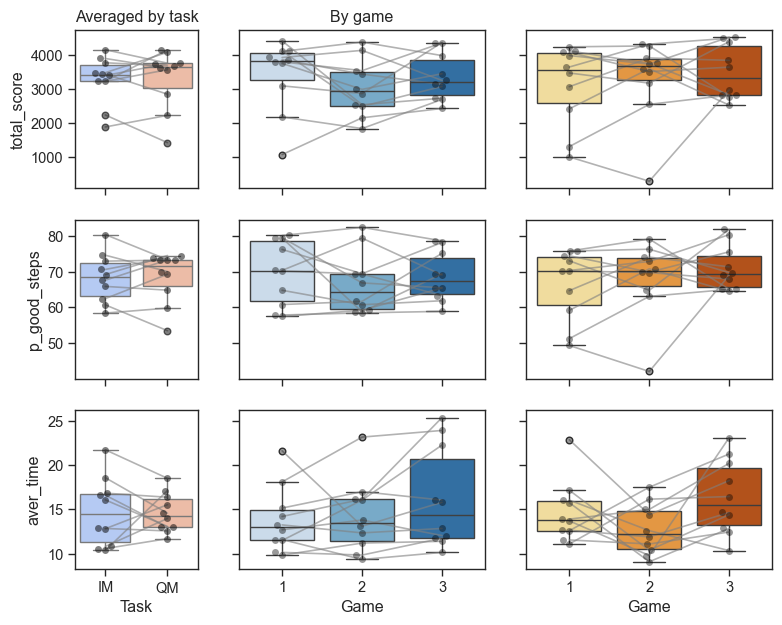

In [225]:
metrics = ['total_score', 'p_good_steps', 'aver_time']
fig, axes = plt.subplots(3, 3, figsize=(9, 7), width_ratios=[1, 2, 2], sharey='row', sharex='col')

for i in range(len(metrics)):
    create_plot(metrics[i], df, df_av, axes[i])
axes[0, 0].set_title('Averaged by task')
axes[0, 1].set_title('By game')
axes[2, 0].set_xlabel('Task')
axes[2, 1].set_xlabel('Game')
axes[2, 2].set_xlabel('Game')

In [6]:
df = df_surv.loc[df_surv['mode'] == 'IM'].copy()

In [32]:
sns.set_style("ticks")
sns.set_context("paper", font_scale=1.2)

(0.0, 1.0)

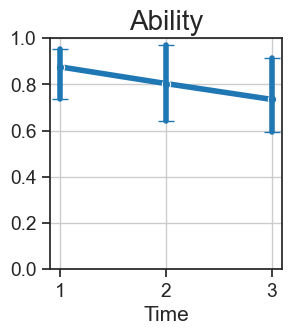

In [69]:
metric = 'Success'
title = 'Ability'

plt.figure(figsize=(3, 3))
sns.set_context( "notebook", font_scale=1.25)
sns.lineplot(df, x='n', y=metric, markers=True, style='mode', linewidth=4, 
             estimator='median', errorbar=('pi', 75), err_style='bars', err_kws={'elinewidth':4, 'capsize':6}, 
             legend=False)
plt.grid()
plt.xticks([1, 2, 3])
plt.ylabel('')
plt.xlabel('Time')
plt.title(title, fontsize=20)
plt.ylim(0, 1)

In [1]:
metric = 'attention' #'Difficulty'
title = 'Vividness' #'Difficulty'

plt.figure(figsize=(3, 3))
sns.set_context( "notebook", font_scale=1.25)
sns.lineplot(df, x='n', y=metric, markers=True, style='mode', linewidth=4, 
             estimator='median', errorbar=('pi', 75), err_style='bars', err_kws={'elinewidth':4, 'capsize':6}, 
             legend=False)
plt.grid()
plt.xticks([1, 2, 3])
plt.ylabel('')
plt.xlabel('Time')
plt.title(title, fontsize=20)
plt.ylim(0, 1)

NameError: name 'plt' is not defined